<a href="https://colab.research.google.com/github/ganginkim2003-code/Biodiversity-Data-Analysis/blob/main/Biodiversity_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Biodiversity Data Analysis Project
Reproducibility Note: This notebook was developed using a 284.1 MB dataset from GBIF and IUCN stored on a private Google Drive. The raw data is not included as to stay within GitHub's file size limits.

To run this notebook, download the raw biological data files and update the path variables.


## Part 1: Cleaning

In [31]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [32]:
import pandas as pd
!unzip -o "/content/drive/MyDrive/Biodiversity Data/biodiversityproject_data.zip" -d "/content/biodiversity_data"

Archive:  /content/drive/MyDrive/Biodiversity Data/biodiversityproject_data.zip
mapname:  conversion of  failed
 extracting: /content/biodiversity_data/IUCN_plants.csv  
 extracting: /content/biodiversity_data/GBIF_can_us.csv  
 extracting: /content/biodiversity_data/IUCN_animals.csv  
 extracting: /content/biodiversity_data/GBIF_n_europe.csv  
 extracting: /content/biodiversity_data/GBIF_east_asia.csv  
 extracting: /content/biodiversity_data/GBIF_east_africa.csv  
 extracting: /content/biodiversity_data/Amniote_Database_Aug_2015.csv  
 extracting: /content/biodiversity_data/GBIF_south_america_tropics.csv  


In [33]:
GBIF_us_can_raw = pd.read_table('/content/biodiversity_data/GBIF_can_us.csv')
GBIF_east_africa_raw = pd.read_table('/content/biodiversity_data/GBIF_east_africa.csv')
GBIF_east_asia_raw = pd.read_table('/content/biodiversity_data/GBIF_east_asia.csv')
GBIF_europe_raw = pd.read_table('/content/biodiversity_data/GBIF_n_europe.csv')
GBIF_tropics_raw = pd.read_table('/content/biodiversity_data/GBIF_south_america_tropics.csv')

iucn_raw = pd.read_csv('/content/biodiversity_data/IUCN_animals.csv')
iucn_raw

,assessmentId,internalTaxonId,scientificName,kingdomName,phylumName,orderName,className,familyName,genusName,speciesName,infraType,infraName,infraAuthority,authority,redlistCategory,redlistCriteria,criteriaVersion,populationTrend,scopes
0,495630,10030,Hexanchus griseus,ANIMALIA,CHORDATA,HEXANCHIFORMES,CHONDRICHTHYES,HEXANCHIDAE,Hexanchus,griseus,NaN,NaN,NaN,"(Bonnaterre, 1788)",Near Threatened,A2bd,3.1,Decreasing,Global
1,495907,10041,Heosemys annandalii,ANIMALIA,CHORDATA,TESTUDINES,REPTILIA,GEOEMYDIDAE,Heosemys,annandalii,NaN,NaN,NaN,"(Boulenger in Annandale &amp; Robinson, 1903)",Critically Endangered,A2cd+4cd,3.1,Decreasing,Global
2,497499,132523146,Hubbsina turneri,ANIMALIA,CHORDATA,CYPRINODONTIFORMES,ACTINOPTERYGII,GOODEIDAE,Hubbsina,turneri,NaN,NaN,NaN,"(de Buen, 1940)",Critically Endangered,"B1ab(i,ii,iii,iv)+2ab(i,ii,iii,iv)",3.1,Decreasing,Global
3,497550,10267,Hungerfordia pelewensis,ANIMALIA,MOLLUSCA,ARCHITAENIOGLOSSA,GASTROPODA,DIPLOMMATINIDAE,Hungerfordia,pelewensis,NaN,NaN,NaN,"Beddome, 1889",Endangered,"B1ab(ii,iii)+2ab(ii,iii)",3.1,Unknown,Global
4,498370,10767,Ictalurus australis,ANIMALIA,CHORDATA,SILURIFORMES,ACTINOPTERYGII,ICTALURIDAE,Ictalurus,australis,NaN,NaN,NaN,"(Meek, 1904)",Data Deficient,NaN,3.1,Decreasing,Global
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83664,209552552,136823,Eptesicus japonensis,ANIMALIA,CHORDATA,CHIROPTERA,MAMMALIA,VESPERTILIONIDAE,Eptesicus,japonensis,NaN,NaN,NaN,"Imaizumi, 1953",Vulnerable,B2ab(iii),3.1,Decreasing,Global
83665,209553422,71529901,Setirostris eleryi,ANIMALIA,CHORDATA,CHIROPTERA,MAMMALIA,MOLOSSIDAE,Setirostris,eleryi,NaN,NaN,NaN,"(Reardon &amp; McKenzie, 2008)",Near Threatened,C2a(i),3.1,Decreasing,Global
83666,209553784,13564,Miniopterus fuscus,ANIMALIA,CHORDATA,CHIROPTERA,MAMMALIA,MINIOPTERIDAE,Miniopterus,fuscus,NaN,NaN,NaN,"Bonhote, 1902",Endangered,B2ab(iii),3.1,Decreasing,Global
83667,209554228,71534469,Ozimops petersi,ANIMALIA,CHORDATA,CHIROPTERA,MAMMALIA,MOLOSSIDAE,Ozimops,petersi,NaN,NaN,NaN,"(Leche, 1884)",Least Concern,NaN,3.1,Unknown,Global


In [34]:
display(GBIF_us_can_raw.head())
display(iucn_raw.head())

,taxonKey,scientificName,acceptedTaxonKey,acceptedScientificName,numberOfOccurrences,taxonRank,taxonomicStatus,kingdom,kingdomKey,phylum,...,classKey,order,orderKey,family,familyKey,genus,genusKey,species,speciesKey,iucnRedListCategory
0,341,Turbellaria,341.0,Turbellaria,106,CLASS,ACCEPTED,Animalia,1,Platyhelminthes,...,341.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,830,Nitrospirales,830.0,Nitrospirales,1014,ORDER,ACCEPTED,Bacteria,3,Nitrospirota,...,10889728.0,Nitrospirales,830.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,982,Neogastropoda,982.0,Neogastropoda,681,ORDER,ACCEPTED,Animalia,1,Mollusca,...,225.0,Neogastropoda,982.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1445,Psittaciformes,1445.0,Psittaciformes,1,ORDER,ACCEPTED,Animalia,1,Chordata,...,212.0,Psittaciformes,1445.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2390,Scrophulariaceae,2390.0,Scrophulariaceae,128,FAMILY,ACCEPTED,Plantae,6,Tracheophyta,...,220.0,Lamiales,408.0,Scrophulariaceae,2390.0,NaN,NaN,NaN,NaN,NE


,assessmentId,internalTaxonId,scientificName,kingdomName,phylumName,orderName,className,familyName,genusName,speciesName,infraType,infraName,infraAuthority,authority,redlistCategory,redlistCriteria,criteriaVersion,populationTrend,scopes
0,495630,10030,Hexanchus griseus,ANIMALIA,CHORDATA,HEXANCHIFORMES,CHONDRICHTHYES,HEXANCHIDAE,Hexanchus,griseus,NaN,NaN,NaN,"(Bonnaterre, 1788)",Near Threatened,A2bd,3.1,Decreasing,Global
1,495907,10041,Heosemys annandalii,ANIMALIA,CHORDATA,TESTUDINES,REPTILIA,GEOEMYDIDAE,Heosemys,annandalii,NaN,NaN,NaN,"(Boulenger in Annandale &amp; Robinson, 1903)",Critically Endangered,A2cd+4cd,3.1,Decreasing,Global
2,497499,132523146,Hubbsina turneri,ANIMALIA,CHORDATA,CYPRINODONTIFORMES,ACTINOPTERYGII,GOODEIDAE,Hubbsina,turneri,NaN,NaN,NaN,"(de Buen, 1940)",Critically Endangered,"B1ab(i,ii,iii,iv)+2ab(i,ii,iii,iv)",3.1,Decreasing,Global
3,497550,10267,Hungerfordia pelewensis,ANIMALIA,MOLLUSCA,ARCHITAENIOGLOSSA,GASTROPODA,DIPLOMMATINIDAE,Hungerfordia,pelewensis,NaN,NaN,NaN,"Beddome, 1889",Endangered,"B1ab(ii,iii)+2ab(ii,iii)",3.1,Unknown,Global
4,498370,10767,Ictalurus australis,ANIMALIA,CHORDATA,SILURIFORMES,ACTINOPTERYGII,ICTALURIDAE,Ictalurus,australis,NaN,NaN,NaN,"(Meek, 1904)",Data Deficient,NaN,3.1,Decreasing,Global


In [35]:
#extract relevant columns for the GBIF datasets, replace blank with missing value, convert to correct dtype

GBIF_imp_columns = ['species']
GBIF_us_can = GBIF_us_can_raw[GBIF_imp_columns].convert_dtypes().replace('', pd.NA)
GBIF_east_africa = GBIF_east_africa_raw[GBIF_imp_columns].convert_dtypes().replace('', pd.NA)
GBIF_east_asia = GBIF_east_asia_raw[GBIF_imp_columns].convert_dtypes().replace('', pd.NA)
GBIF_europe = GBIF_europe_raw[GBIF_imp_columns].convert_dtypes().replace('', pd.NA)
GBIF_tropics = GBIF_tropics_raw[GBIF_imp_columns].convert_dtypes().replace('', pd.NA)

In [36]:
#add new column for location

GBIF_us_can['Geographic Region'] = 'USA/Canada'
GBIF_east_africa['Geographic Region'] = 'East Africa'
GBIF_east_asia['Geographic Region'] = 'East Asia'
GBIF_europe['Geographic Region'] = 'Europe'
GBIF_tropics['Geographic Region'] = 'South American Tropics'

In [37]:
#Combine all GBIF datasets into one Dataframe

combined1 = pd.concat([GBIF_us_can, GBIF_east_africa])
combined2 = pd.concat([combined1, GBIF_east_asia])
combined3 = pd.concat([combined2,GBIF_europe])

GBIF_data_combined = pd.concat([combined3, GBIF_tropics])

display(GBIF_data_combined)


,species,Geographic Region
0,<NA>,USA/Canada
1,<NA>,USA/Canada
2,<NA>,USA/Canada
3,<NA>,USA/Canada
4,<NA>,USA/Canada
...,...,...
293683,Orthotrichum pycnophyllum,South American Tropics
293684,Astyanax pelecus,South American Tropics
293685,<NA>,South American Tropics
293686,Lucilia deceptor,South American Tropics


In [38]:
#extract relevant columns from IUCN dataset, replace NaNn with pd.NA, convert dtype

iucn_imp_column = ['scientificName', 'redlistCategory']
iucn_rename = {'scientificName': 'Scientific Name', 'redlistCategory': 'Red List Category' }

iucn_data = iucn_raw[iucn_imp_column]
iucn_data_renamed = iucn_data.rename(columns = iucn_rename)
iucn_data_clean = iucn_data_renamed.convert_dtypes().replace('NaN', pd.NA)

In [39]:
#Merge IUCN and GBIF dataframes

iucn_gbif_merged = pd.merge(
    left = iucn_data_clean,
    right = GBIF_data_combined,
    left_on = 'Scientific Name',
    right_on = 'species'
)
iucn_gbif_merged

,Scientific Name,Red List Category,species,Geographic Region
0,Hexanchus griseus,Near Threatened,Hexanchus griseus,USA/Canada
1,Hexanchus griseus,Near Threatened,Hexanchus griseus,USA/Canada
2,Hexanchus griseus,Near Threatened,Hexanchus griseus,Europe
3,Hexanchus griseus,Near Threatened,Hexanchus griseus,South American Tropics
4,Ambloplites cavifrons,Least Concern,Ambloplites cavifrons,USA/Canada
...,...,...,...,...
69331,Plecotus sacrimontis,Least Concern,Plecotus sacrimontis,East Asia
69332,Ozimops beccarii,Least Concern,Ozimops beccarii,USA/Canada
69333,Miniopterus fuscus,Endangered,Miniopterus fuscus,East Asia
69334,Carassius cuvieri,Endangered,Carassius cuvieri,East Africa


## Part 2: Computations

In [40]:
# Filter the merged data frame to only include species which are Endangered or Critically Endangered

is_end = iucn_gbif_merged["Red List Category"] == "Endangered"
is_cr = iucn_gbif_merged["Red List Category"] == "Critically Endangered"
iucn_gbif_endangered = iucn_gbif_merged[is_end|is_cr]
iucn_gbif_endangered

,Scientific Name,Red List Category,species,Geographic Region
6,Ameca splendens,Critically Endangered,Ameca splendens,USA/Canada
9,Lampsilis rafinesqueana,Endangered,Lampsilis rafinesqueana,USA/Canada
10,Lampsilis rafinesqueana,Endangered,Lampsilis rafinesqueana,USA/Canada
12,Hamiota altilis,Endangered,Hamiota altilis,USA/Canada
13,Hamiota altilis,Endangered,Hamiota altilis,USA/Canada
...,...,...,...,...
69318,Myotis lucifugus,Endangered,Myotis lucifugus,East Africa
69319,Myotis lucifugus,Endangered,Myotis lucifugus,East Asia
69333,Miniopterus fuscus,Endangered,Miniopterus fuscus,East Asia
69334,Carassius cuvieri,Endangered,Carassius cuvieri,East Africa


In [41]:
USA = iucn_gbif_endangered["Geographic Region"] == "USA/Canada"
East_Africa = iucn_gbif_endangered["Geographic Region"] == "East Africa"
East_Asia = iucn_gbif_endangered["Geographic Region"] == "East Asia"
Europe = iucn_gbif_endangered["Geographic Region"] == "Europe"
SA_Tropics = iucn_gbif_endangered["Geographic Region"] == "South American Tropics"
SAT_endangered_dataframe = iucn_gbif_endangered[SA_Tropics]
EU_endangered_dataframe = iucn_gbif_endangered[Europe]
EAS_endangered_dataframe = iucn_gbif_endangered[East_Asia]
EAF_endangered_dataframe = iucn_gbif_endangered[East_Africa]
US_endangered_dataframe = iucn_gbif_endangered[USA]
EAF_endangered_dataframe

,Scientific Name,Red List Category,species,Geographic Region
66,Malacochersus tornieri,Critically Endangered,Malacochersus tornieri,East Africa
857,Centrochelys sulcata,Endangered,Centrochelys sulcata,East Africa
1211,Polysteganus undulosus,Critically Endangered,Polysteganus undulosus,East Africa
1238,Petrus rupestris,Endangered,Petrus rupestris,East Africa
1419,Rhampholeon acuminatus,Critically Endangered,Rhampholeon acuminatus,East Africa
...,...,...,...,...
69072,Trigonoceps occipitalis,Critically Endangered,Trigonoceps occipitalis,East Africa
69073,Aquila nipalensis,Endangered,Aquila nipalensis,East Africa
69074,Aquila nipalensis,Endangered,Aquila nipalensis,East Africa
69318,Myotis lucifugus,Endangered,Myotis lucifugus,East Africa


In [42]:
USA_prop = US_endangered_dataframe.shape[0]/GBIF_us_can.shape[0]
EAf_prop = EAF_endangered_dataframe.shape[0]/GBIF_east_africa.shape[0]
EAs_prop = EAS_endangered_dataframe.shape[0]/GBIF_east_asia.shape[0]
EU_prop = EU_endangered_dataframe.shape[0]/GBIF_europe.shape[0]
SA_prop = SAT_endangered_dataframe.shape[0]/GBIF_tropics.shape[0]

In [43]:
print(USA_prop)
print(EAf_prop)
print(EAs_prop)
print(EU_prop)
print(SA_prop)

0.002799081676641904
0.0055249923263995466
0.002189903703557234
0.000644907866117127
0.004058728991310506


In [44]:
prop_dict = {
    "USA": USA_prop,
    "East Africa": EAf_prop,
    "East Asia": EAs_prop,
    "Europe": EU_prop,
    "South American Tropics": SA_prop
}

In [45]:
end_ser = pd.Series(data=prop_dict, name="Proportion of Endangered Species by Region")
end_ser

,Proportion of Endangered Species by Region
USA,0.002799
East Africa,0.005525
East Asia,0.002190
Europe,0.000645
South American Tropics,0.004059


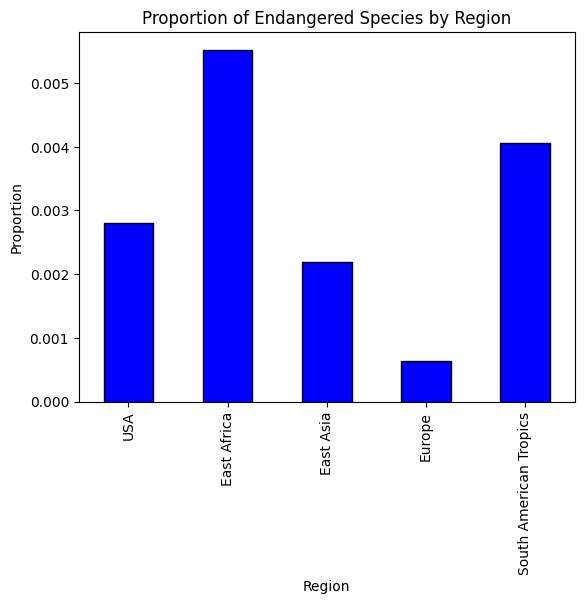

In [46]:
import matplotlib.pyplot as plt

end_ser.plot(kind='bar', color='blue', edgecolor='black')

plt.title("Proportion of Endangered Species by Region")
plt.xlabel("Region")
plt.ylabel("Proportion")
plt.show()